# Transfer Learning on Videos - Action Recognition

In [19]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [20]:
# Constants
IMAGE_SIZE = 64
FRAMES = 8
NUM_CLASSES = 3
BATCH_SIZE = 1

# Load Dataset

In [21]:
# Dataset Generator
def make_synthetic_dataset(num_samples):
    def _generator():
        for i in range(num_samples):
            video = tf.random.uniform([FRAMES, IMAGE_SIZE, IMAGE_SIZE, 3], dtype=tf.float32)
            label = tf.random.uniform([], minval=0, maxval=NUM_CLASSES, dtype=tf.int32)
            yield video, label

    output_signature = (
        tf.TensorSpec(shape=(FRAMES, IMAGE_SIZE, IMAGE_SIZE, 3), dtype=tf.float32),
        tf.TensorSpec(shape=(), dtype=tf.int32)
    )
    return tf.data.Dataset.from_generator(_generator, output_signature=output_signature)

train_ds = make_synthetic_dataset(20).batch(BATCH_SIZE).prefetch(1)
val_ds = make_synthetic_dataset(10).batch(BATCH_SIZE).prefetch(1)

# 3D Conv Model

In [22]:
# 3D Conv Model
def build_lightweight_video_model():
    inputs = tf.keras.Input(shape=(FRAMES, IMAGE_SIZE, IMAGE_SIZE, 3))
    x = tf.keras.layers.Conv3D(8, kernel_size=(3, 3, 3), activation='relu')(inputs)
    x = tf.keras.layers.MaxPooling3D(pool_size=(2, 2, 2))(x)
    x = tf.keras.layers.Flatten()(x)
    x = tf.keras.layers.Dense(32, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.2)(x)
    outputs = tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')(x)
    return tf.keras.Model(inputs, outputs)

In [23]:
# Build and compile the model
model = build_lightweight_video_model()
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train Model

In [24]:
# Train the model
history = model.fit(train_ds, validation_data=val_ds, epochs=5)

Epoch 1/5
     16/Unknown 2s 3ms/step - accuracy: 0.0777 - loss: 2.4608   

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:151: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.1101 - loss: 2.3207 - val_accuracy: 0.5000 - val_loss: 1.0897
Epoch 2/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5017 - loss: 1.0060 - val_accuracy: 0.5000 - val_loss: 1.4294
Epoch 3/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2216 - loss: 1.0971 - val_accuracy: 0.6000 - val_loss: 1.0991
Epoch 4/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.2004 - loss: 1.0997 - val_accuracy: 0.4000 - val_loss: 1.0918
Epoch 5/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4587 - loss: 1.0906 - val_accuracy: 0.2000 - val_loss: 1.1184


# Training Curves

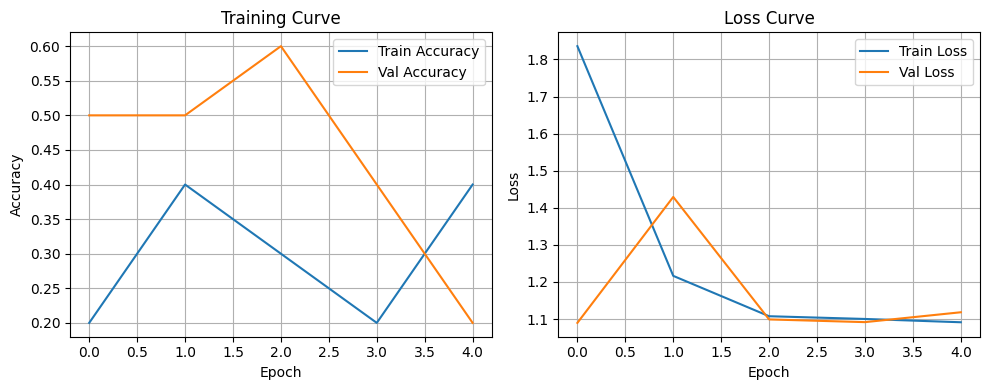

In [25]:
# Plotting training curves
plt.figure(figsize=(10,4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title("Training Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Confusion Matrix

In [26]:
# Collect predictions for confusion matrix
y_true = []
y_pred = []

for videos, labels in val_ds:
    preds = model.predict(videos, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

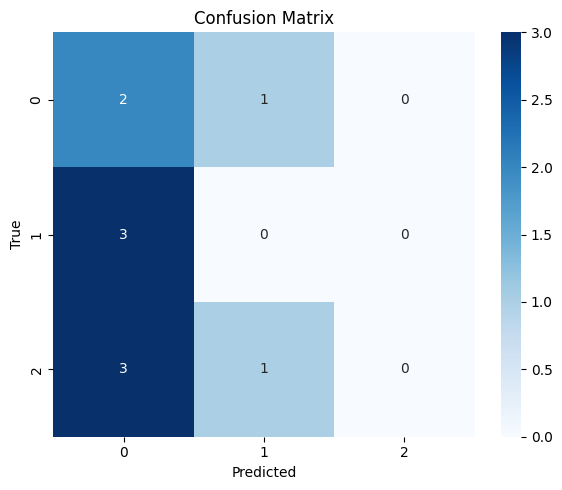

In [27]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=range(NUM_CLASSES), yticklabels=range(NUM_CLASSES))
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

# Visualizing Videos

In [28]:
# Visualize a few synthetic video clips
def show_video_clip(video_tensor):
    fig, axes = plt.subplots(1, FRAMES, figsize=(FRAMES * 1.2, 2))
    for i in range(FRAMES):
        axes[i].imshow(video_tensor[i])
        axes[i].axis('off')
    plt.suptitle("Sample Video Frames")
    plt.tight_layout()
    plt.show()

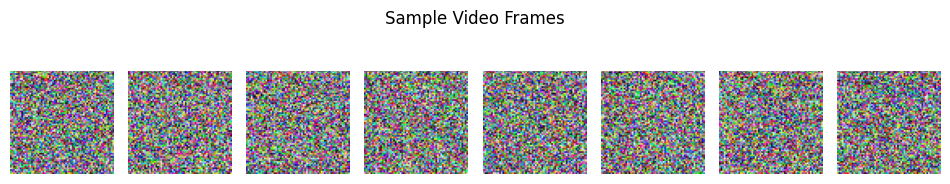

In [29]:
# Display one random video
for videos, labels in train_ds.take(1):
    show_video_clip(videos[0])